## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

!pip install -q evaluate sacrebleu subword-nmt nltk pandas matplotlib


In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
File ‘data.txt’ already there; not retrieving.



#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:

import os
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.tokenize import WordPunctTokenizer
import nltk
nltk.download('punkt')

import evaluate
metric = evaluate.load("sacrebleu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [4]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# читаем tsv: в файле сначала trg (en), потом src (ru)
df = pd.read_csv(path_do_data, sep="\t", header=None, names=["trg", "src"])

# убираем пустые строки и дубликаты
df = df.dropna()
df["src"] = df["src"].astype(str).str.strip()
df["trg"] = df["trg"].astype(str).str.strip()
df = df[(df["src"] != "") & (df["trg"] != "")]
df = df.drop_duplicates().reset_index(drop=True)

print("Размер датасета:", len(df))
print(df.head())

Размер датасета: 48225
                                                 trg  \
0  Cordelia Hotel is situated in Tbilisi, a 3-min...   
1  At Tupirmarka Lodge you will find a 24-hour fr...   
2  Featuring free WiFi in all areas, Naigao Xiaow...   
3  Each has a TV and a private bathroom with shower.   
4  Your room comes with air conditioning and sate...   

                                                 src  
0  Отель Cordelia расположен в Тбилиси, в 3 минут...  
1  В числе удобств лоджа Tupirmarka круглосуточна...  
2  Апартаменты Naigao Xiaowo расположены в городе...  
3  В вашем распоряжении также телевизор и собстве...  
4  Номер оснащен кондиционером и спутниковым теле...  


In [6]:
train_data, temp_data = train_test_split(df, test_size=0.20, random_state=42, shuffle=True)
valid_data, test_data = train_test_split(temp_data, test_size=0.25, random_state=42, shuffle=True)

print("Number of training examples: ", len(train_data))
print("Number of validation examples: ", len(valid_data))
print("Number of testing examples:", len(test_data))

Number of training examples:  38580
Number of validation examples:  7233
Number of testing examples: 2412


In [7]:
from collections import Counter

SPECIAL_TOKENS = ['<pad>', '<unk>', '<sos>', '<eos>']

def build_vocab_from_dataframe(df, text_column, tokenizer, min_freq=3):
    counter = Counter()

    for text in df[text_column].tolist():
        tokens = tokenizer(text)
        counter.update(tokens)

    vocab = {}
    itos = []

    for token in SPECIAL_TOKENS:
        vocab[token] = len(vocab)
        itos.append(token)

    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)
            itos.append(token)

    return vocab, itos, counter

SRC_vocab, SRC_itos, SRC_counter = build_vocab_from_dataframe(
    train_data, text_column="src", tokenizer=tokenize, min_freq=3
)

TRG_vocab, TRG_itos, TRG_counter = build_vocab_from_dataframe(
    train_data, text_column="trg", tokenizer=tokenize, min_freq=3
)

In [8]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC_vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG_vocab)}")

Unique tokens in source (ru) vocabulary: 9283
Unique tokens in target (en) vocabulary: 6700


Here are tokens from original (RU) corpus:

In [9]:
SRC_itos[::1000]

['<pad>',
 'многочисленных',
 'les',
 'ней',
 'известный',
 'аэроэкспресс',
 'баню',
 'изысканных',
 'кемера',
 'треккинг']

And from target (EN) corpus:

In [10]:
TRG_itos[::1000]

['<pad>', 'foot', 'imperiale', 'lua', 'etienne', 'classics', 'helsingborg']

And here is example from train dataset:

In [11]:
print(train_data.iloc[9].to_dict())

{'trg': 'The B&B’s interior features wood floors and large windows.', 'src': 'В этом отеле типа «постель и завтрак» установлены большие окна, а интерьер отделан деревом.'}


Let's check the length distributions:

Length distribution in Train data


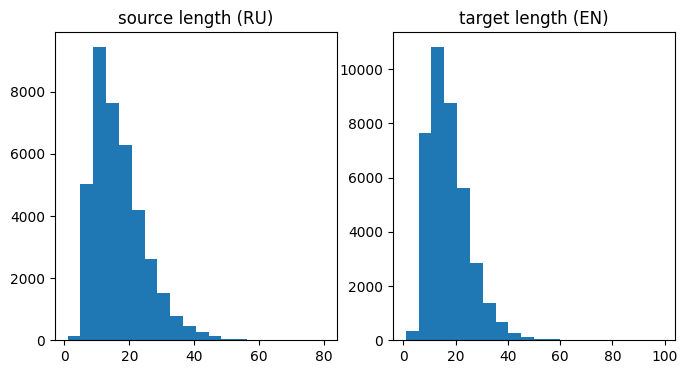

In [12]:
src_length = train_data["src"].apply(lambda x: len(tokenize(x)))
trg_length = train_data["trg"].apply(lambda x: len(tokenize(x)))

print("Length distribution in Train data")

plt.figure(figsize=[8, 4])

plt.subplot(1, 2, 1)
plt.title("source length (RU)")
plt.hist(src_length, bins=20)

plt.subplot(1, 2, 2)
plt.title("target length (EN)")
plt.hist(trg_length, bins=20)

plt.show()

Length distribution in Test data


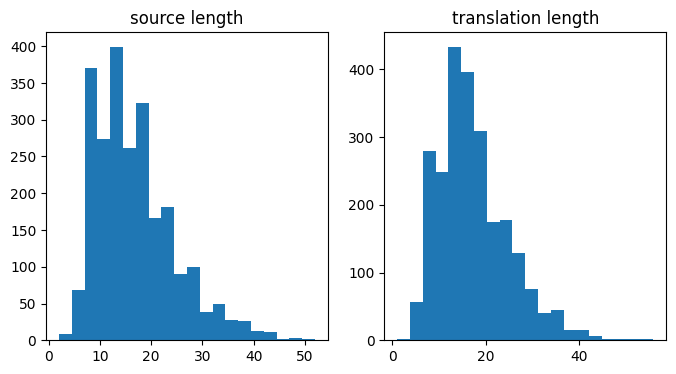

In [13]:
src_length = test_data["src"].apply(lambda x: len(tokenize(x)))
trg_length = test_data["trg"].apply(lambda x: len(tokenize(x)))

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])

plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(src_length, bins=20)

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(trg_length, bins=20)

plt.show()

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
device

device(type='cpu')

In [16]:
from torch.utils.data import Dataset, DataLoader

PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'

PAD_IDX_SRC = SRC_vocab[PAD_TOKEN]
UNK_IDX_SRC = SRC_vocab[UNK_TOKEN]
SOS_IDX_SRC = SRC_vocab[SOS_TOKEN]
EOS_IDX_SRC = SRC_vocab[EOS_TOKEN]

PAD_IDX_TRG = TRG_vocab[PAD_TOKEN]
UNK_IDX_TRG = TRG_vocab[UNK_TOKEN]
SOS_IDX_TRG = TRG_vocab[SOS_TOKEN]
EOS_IDX_TRG = TRG_vocab[EOS_TOKEN]


def encode_tokens(tokens, vocab, unk_idx):
    return [vocab.get(token, unk_idx) for token in tokens]


class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, trg_vocab, tokenizer):
        self.dataframe = dataframe.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        src_tokens = self.tokenizer(row["src"])
        trg_tokens = self.tokenizer(row["trg"])

        src_ids = [SOS_IDX_SRC] + encode_tokens(src_tokens, self.src_vocab, UNK_IDX_SRC) + [EOS_IDX_SRC]
        trg_ids = [SOS_IDX_TRG] + encode_tokens(trg_tokens, self.trg_vocab, UNK_IDX_TRG) + [EOS_IDX_TRG]

        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "trg_ids": torch.tensor(trg_ids, dtype=torch.long),
            "src_len": len(src_ids),
            "trg_len": len(trg_ids)
        }


def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x["src_len"], reverse=True)

    src_seqs = [item["src_ids"] for item in batch]
    trg_seqs = [item["trg_ids"] for item in batch]

    src_padded = nn.utils.rnn.pad_sequence(src_seqs, padding_value=PAD_IDX_SRC)
    trg_padded = nn.utils.rnn.pad_sequence(trg_seqs, padding_value=PAD_IDX_TRG)

    return src_padded.to(device), trg_padded.to(device)


BATCH_SIZE = 32

train_dataset = TranslationDataset(train_data, SRC_vocab, TRG_vocab, tokenize)
valid_dataset = TranslationDataset(valid_data, SRC_vocab, TRG_vocab, tokenize)
test_dataset = TranslationDataset(test_data, SRC_vocab, TRG_vocab, tokenize)

train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iterator = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_iterator)}")
print(f"Valid batches: {len(valid_iterator)}")
print(f"Test batches: {len(test_iterator)}")

Train batches: 1206
Valid batches: 227
Test batches: 76


In [17]:
for src_batch, trg_batch in train_iterator:
    break

print("Source batch:")
print(src_batch)
print("Target batch:")
print(trg_batch)

print(src_batch.shape, trg_batch.shape)

Source batch:
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [ 462,   10, 1704,  ...,   10, 1418,   10],
        [ 111, 1047, 5690,  ...,   43, 1101,  161],
        ...,
        [   1,   27,    0,  ...,    0,    0,    0],
        [  27,    3,    0,  ...,    0,    0,    0],
        [   3,    0,    0,  ...,    0,    0,    0]])
Target batch:
tensor([[  2,   2,   2,  ...,   2,   2,   2],
        [ 97, 340, 107,  ...,  29, 472,   4],
        [ 61, 842,  61,  ..., 385,  31, 140],
        ...,
        [ 16,   0, 168,  ...,   0,   0,   0],
        [  3,   0,  16,  ...,   0,   0,   0],
        [  0,   0,   3,  ...,   0,   0,   0]])
torch.Size([35, 32]) torch.Size([33, 32])


In [18]:
import torch
import torch.nn as nn
import random


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, src):
        # src = [src sent len, batch size]
        embedded = self.embedding(src)
        embedded = self.dropout(embedded)
        output, (hidden, cell) = self.rnn(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.output_dim = output_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            num_embeddings=output_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.out = nn.Linear(
            in_features=hid_dim,
            out_features=output_dim
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, input, hidden, cell):
        # input = [batch size]
        input = input.unsqueeze(0)  # [1, batch size]

        embedded = self.dropout(self.embedding(input))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.out(output.squeeze(0))

        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src sent len, batch size]
        # trg = [trg sent len, batch size]

        batch_size = trg.shape[1]
        max_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(max_len, batch_size, trg_vocab_size).to(self.device)

        hidden, cell = self.encoder(src)
        input = trg[0, :]

        for t in range(1, max_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.max(1)[1]
            input = trg[t] if teacher_force else top1

        return outputs

In [19]:
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 1
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.3

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [20]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9283, 128)
    (rnn): LSTM(128, 256, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(6700, 128)
    (rnn): LSTM(128, 256, dropout=0.3)
    (out): Linear(in_features=256, out_features=6700, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 4,558,252 trainable parameters


In [22]:
PAD_IDX = TRG_vocab['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [39]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []

    for i, (src, trg) in enumerate(iterator):
        optimizer.zero_grad()

        output = model(src, trg)

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()
        history.append(loss.item())

        if (i + 1) % 20 == 0:
            print(f'Batch {i+1}/{len(iterator)} | loss = {loss.item():.3f}')

    return epoch_loss / len(iterator)

In [43]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            output = model(src, trg, 0)

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

            if (i + 1) % 20 == 0:
                print(f'Validation batch {i+1}/{len(iterator)} | loss = {loss.item():.3f}')

    return epoch_loss / len(iterator)

In [44]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [45]:
train_history = []
valid_history = []

N_EPOCHS = 2
CLIP = 1

best_valid_loss = float('inf')

In [30]:
from IPython.display import clear_output

In [ ]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

Batch 20/1206 | loss = 4.406
Batch 40/1206 | loss = 4.013
Batch 60/1206 | loss = 4.281
Batch 80/1206 | loss = 4.274
Batch 100/1206 | loss = 4.555
Batch 120/1206 | loss = 4.182
Batch 140/1206 | loss = 4.446
Batch 160/1206 | loss = 4.822
Batch 180/1206 | loss = 3.934
Batch 200/1206 | loss = 4.157
Batch 220/1206 | loss = 4.029
Batch 240/1206 | loss = 4.065
Batch 260/1206 | loss = 4.582
Batch 280/1206 | loss = 4.287
Batch 300/1206 | loss = 4.052
Batch 320/1206 | loss = 3.869
Batch 340/1206 | loss = 4.239
Batch 360/1206 | loss = 4.316
Batch 380/1206 | loss = 4.177
Batch 400/1206 | loss = 4.040
Batch 420/1206 | loss = 4.342
Batch 440/1206 | loss = 4.041
Batch 460/1206 | loss = 4.346
Batch 480/1206 | loss = 3.813
Batch 500/1206 | loss = 4.171
Batch 520/1206 | loss = 4.436
Batch 540/1206 | loss = 4.339
Batch 560/1206 | loss = 4.016
Batch 580/1206 | loss = 4.395
Batch 600/1206 | loss = 4.198
Batch 620/1206 | loss = 4.348
Batch 640/1206 | loss = 3.778
Batch 660/1206 | loss = 4.312
Batch 680/1206

__Let's take a look at our network quality__:

In [ ]:
del utils

In [ ]:
import utils
import imp
imp.reload(utils)
generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [ ]:
batch = next(iter(test_iterator))

In [ ]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [ ]:
import tqdm

In [ ]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

In [ ]:
corpus_bleu([[text] for text in original_text], generated_text) * 100